# Phase 3: MobileNetV2 Transfer Learning

In this phase, we will build, train, and evaluate a MobileNetV2 transfer-learning model.

In [2]:
#Import Libraries

import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

**Project Paths**

In [3]:
project_path = "/home/arslan/projects/skin-lesion-classifier"
processed_path = project_path + "/data/processed"

print("Processed data folder:", processed_path)

Processed data folder: /home/arslan/projects/skin-lesion-classifier/data/processed


**Load the Saved Dataset Splits**

In [4]:
train_df = pd.read_csv(processed_path + "/train.csv")
val_df = pd.read_csv(processed_path + "/validation.csv")
test_df = pd.read_csv(processed_path + "/test.csv")

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

Training images: 7014
Validation images: 1509
Testing images: 1492


**Set image size and batch size**

In [6]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 32


**Calculate Class Weights**

In [7]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weight_dict = dict(enumerate(class_weights.tolist()))

print(class_weight_dict)

{0: 4.263829787234043, 1: 2.745205479452055, 2: 1.3324468085106382, 3: 12.683544303797468, 4: 1.2651515151515151, 5: 0.21364605543710022, 6: 9.92079207920792}


**Training Image Preprocessing**

In [8]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True
)

**Validation and Test Preprocessing**

In [9]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

**Training Generator**

In [10]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=True
)

Found 7014 validated image filenames.


**Validation Generator**

In [11]:
validation_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

Found 1509 validated image filenames.


**Test Generator**

In [12]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

Found 1492 validated image filenames.


**Load MobileNetV2 Base Model**

In [14]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

**Freeze MobileNetV2 Base Model**

In [15]:
base_model.trainable = False

print("Base model trainable:", base_model.trainable)

Base model trainable: False


Freezes the pretrained MobileNetV2 layers so their weights do not change during initial training.

**Build Transfer-Learning Model**

In [ ]:
mobilenet_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(7, activation="softmax")
])

In [17]:
#Compile the model

mobilenet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
mobilenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Training Callbacks**

In [19]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        project_path + "/models/mobilenet/best_mobilenet.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

**Train Frozen MobileNetV2 Model**

In [20]:
history = mobilenet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/15


I0000 00:00:1781910093.882712  454403 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1781910096.960280  456523 service.cc:153] XLA service 0x7883d0033540 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781910096.960313  456523 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1781910097.072730  456523 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781910097.938164  456523 cuda_dnn.cc:461] Loaded cuDNN version 92302
I0000 00:00:1781910098.017693  456523 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9903__.118
E0000 00:00:1781910100.348912  456523 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup

  1/220 ━━━━━━━━━━━━━━━━━━━━ 1:06:25 18s/step - accuracy: 0.0625 - loss: 3.5892

I0000 00:00:1781910112.014292  456523 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


134/220 ━━━━━━━━━━━━━━━━━━━━ 33s 384ms/step - accuracy: 0.2647 - loss: 2.3396

I0000 00:00:1781910163.927584  456522 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9903__.118
E0000 00:00:1781910164.479100  456522 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.3112 - loss: 2.1579

E0000 00:00:1781910223.681979  456523 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


220/220 ━━━━━━━━━━━━━━━━━━━━ 133s 523ms/step - accuracy: 0.4029 - loss: 1.7998 - val_accuracy: 0.5076 - val_loss: 1.3451
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 84s 383ms/step - accuracy: 0.5295 - loss: 1.3155 - val_accuracy: 0.4546 - val_loss: 1.4160
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 89s 405ms/step - accuracy: 0.5838 - loss: 1.1544 - val_accuracy: 0.5818 - val_loss: 1.1569
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 86s 389ms/step - accuracy: 0.5934 - loss: 1.1114 - val_accuracy: 0.6501 - val_loss: 0.9756
Epoch 5/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 91s 415ms/step - accuracy: 0.5897 - loss: 1.0855 - val_accuracy: 0.6667 - val_loss: 0.9104
Epoch 6/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 85s 389ms/step - accuracy: 0.6051 - loss: 1.0186 - val_accuracy: 0.5759 - val_loss: 1.1093
Epoch 7/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 85s 386ms/step - accuracy: 0.6329 - loss: 0.9788 - val_accuracy: 0.5964 - val_loss: 1.0921
Epoch 8/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 83s 379ms/step - accuracy: 0.6303 - loss: 0.9472 - va

In [21]:
best_epoch = np.argmin(history.history["val_loss"])

print("Epochs completed:", len(history.history["loss"]))
print("Best epoch:", best_epoch + 1)
print("Training accuracy:", history.history["accuracy"][best_epoch])
print("Validation accuracy:", history.history["val_accuracy"][best_epoch])
print("Training loss:", history.history["loss"][best_epoch])
print("Validation loss:", history.history["val_loss"][best_epoch])

Epochs completed: 8
Best epoch: 5
Training accuracy: 0.5896778106689453
Validation accuracy: 0.6666666865348816
Training loss: 1.0855251550674438
Validation loss: 0.9104427695274353


**Evaluate the trained model**

In [22]:
test_generator.reset()

test_loss, test_accuracy = mobilenet_model.evaluate(
    test_generator
)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7100 - loss: 0.8760

E0000 00:00:1781911004.138635  456521 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 311ms/step - accuracy: 0.6957 - loss: 0.9000
Test accuracy: 0.6957104802131653
Test loss: 0.899969756603241


**Generate Test Predictions**

In [23]:
test_generator.reset()

predictions = mobilenet_model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)

print("Predictions:", len(predicted_labels))

47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 245ms/step
Predictions: 1492


**Get the true test labels**

In [24]:
true_labels = test_df["label"].to_numpy()

print("True labels:", len(true_labels))

True labels: 1492


**Classification Report**

In [26]:
from sklearn.metrics import classification_report

class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       akiec     0.4000    0.3333    0.3636        42
         bcc     0.4820    0.8816    0.6233        76
         bkl     0.4469    0.4790    0.4624       167
          df     0.1905    0.4211    0.2623        19
         mel     0.4008    0.5975    0.4798       159
          nv     0.9239    0.7485    0.8270      1006
        vasc     0.4667    0.9130    0.6176        23

    accuracy                         0.6957      1492
   macro avg     0.4730    0.6249    0.5194      1492
weighted avg     0.7611    0.6957    0.7154      1492



**Confusion Matrix**

In [28]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(
    true_labels,
    predicted_labels
)

print(confusion)

[[ 14   9   6   3   9   1   0]
 [  1  67   3   0   2   2   1]
 [ 10  20  80   6  27  23   1]
 [  0   4   2   8   2   3   0]
 [  3   8  17   4  95  32   0]
 [  7  31  71  21 101 753  22]
 [  0   0   0   0   1   1  21]]


**Display Confusion Matrix**

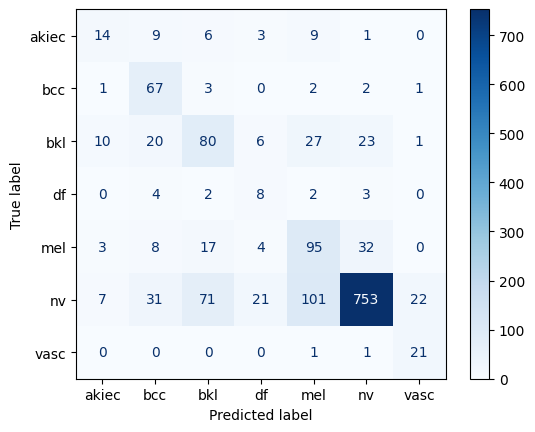

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(cmap="Blues")

**Final Evaluation Metrics**

In [29]:
weighted_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="weighted"
)

macro_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="macro"
)

melanoma_recall = recall_score(
    true_labels == 4,
    predicted_labels == 4
)

melanoma_precision = precision_score(
    true_labels == 4,
    predicted_labels == 4
)

print("Weighted F1-score:", weighted_f1)
print("Macro F1-score:", macro_f1)
print("Melanoma recall:", melanoma_recall)
print("Melanoma precision:", melanoma_precision)

Weighted F1-score: 0.7153640757372018
Macro F1-score: 0.5194397379649075
Melanoma recall: 0.5974842767295597
Melanoma precision: 0.4008438818565401


**Save Trained MobileNetV2 Model**

In [30]:
mobilenet_model.save(
    project_path + "/models/mobilenet/mobilenetv2_model.keras"
)

print("MobileNetV2 model saved successfully.")

MobileNetV2 model saved successfully.


**Plot Training & Validation Accuracy**

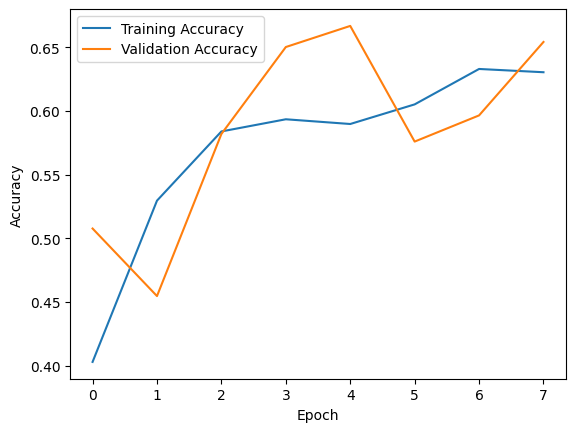

In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Plot Training & Validation Loss**

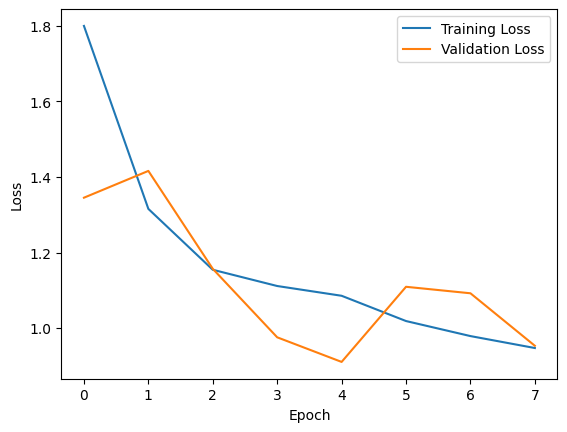

In [32]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Compare MobileNetV2 with Baseline CNN

In [35]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline CNN", "MobileNetV2"],
    "Test Accuracy": [0.4578, test_accuracy],
    "Weighted F1": [0.4988, weighted_f1],
    "Macro F1": [0.1461, macro_f1],
    "Melanoma Recall": [0.2830, melanoma_recall],
    "Melanoma Precision": [0.1685, melanoma_precision]
})

comparison_df

,Model,Test Accuracy,Weighted F1,Macro F1,Melanoma Recall,Melanoma Precision
0,Baseline CNN,0.45780,0.498800,0.14610,0.283000,0.168500
1,MobileNetV2,0.69571,0.715364,0.51944,0.597484,0.400844


### Fine-Tune the Model

**Unfreeze Last 20 MobileNetV2 Layers**

In [36]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Trainable base layers:", sum(layer.trainable for layer in base_model.layers))

Trainable base layers: 20


**Recompile With Small Learning Rate**

In [37]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**Create Fine-Tuning Callbacks**

In [38]:
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        project_path + "/models/mobilenet/best_finetuned_mobilenet.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

**Fine-tune the Model**

In [39]:
fine_tune_history = mobilenet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=fine_tune_callbacks
)

Epoch 1/10


I0000 00:00:1781912204.707649  456522 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39390__.146


 20/220 ━━━━━━━━━━━━━━━━━━━━ 1:09 348ms/step - accuracy: 0.5119 - loss: 1.5157

I0000 00:00:1781912219.387678  456522 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39390__.146


220/220 ━━━━━━━━━━━━━━━━━━━━ 127s 503ms/step - accuracy: 0.4942 - loss: 1.3365 - val_accuracy: 0.6892 - val_loss: 0.8458
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 99s 449ms/step - accuracy: 0.5287 - loss: 1.1386 - val_accuracy: 0.6839 - val_loss: 0.8737
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 93s 424ms/step - accuracy: 0.5537 - loss: 1.0807 - val_accuracy: 0.6865 - val_loss: 0.8601
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 91s 414ms/step - accuracy: 0.5654 - loss: 0.9888 - val_accuracy: 0.6793 - val_loss: 0.8699


**Evaluate Fine-Tuned Model**

In [40]:
test_generator.reset()

fine_tune_test_loss, fine_tune_test_accuracy = mobilenet_model.evaluate(
    test_generator
)

print("Fine-tuned test accuracy:", fine_tune_test_accuracy)
print("Fine-tuned test loss:", fine_tune_test_loss)

47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 327ms/step - accuracy: 0.7111 - loss: 0.8498
Fine-tuned test accuracy: 0.7111260294914246
Fine-tuned test loss: 0.84982830286026


**Generate Fine-Tuned Predictions**

In [41]:
test_generator.reset()

fine_tune_predictions = mobilenet_model.predict(test_generator)

fine_tune_predicted_labels = np.argmax(
    fine_tune_predictions,
    axis=1
)

print("Predictions:", len(fine_tune_predicted_labels))

47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 212ms/step
Predictions: 1492


**Classification Report**

In [42]:
print(
    classification_report(
        true_labels,
        fine_tune_predicted_labels,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       akiec     0.5000    0.2619    0.3438        42
         bcc     0.3696    0.8947    0.5231        76
         bkl     0.4932    0.4311    0.4601       167
          df     0.1429    0.1579    0.1500        19
         mel     0.4545    0.5346    0.4913       159
          nv     0.9102    0.7962    0.8494      1006
        vasc     0.4038    0.9130    0.5600        23

    accuracy                         0.7111      1492
   macro avg     0.4677    0.5699    0.4825      1492
weighted avg     0.7583    0.7111    0.7234      1492



**Final Fine-Tuning Metrics**

In [43]:
fine_tune_weighted_f1 = f1_score(
    true_labels,
    fine_tune_predicted_labels,
    average="weighted"
)

fine_tune_macro_f1 = f1_score(
    true_labels,
    fine_tune_predicted_labels,
    average="macro"
)

fine_tune_melanoma_recall = recall_score(
    true_labels == 4,
    fine_tune_predicted_labels == 4,
    zero_division=0
)

fine_tune_melanoma_precision = precision_score(
    true_labels == 4,
    fine_tune_predicted_labels == 4,
    zero_division=0
)

print("Weighted F1-score:", fine_tune_weighted_f1)
print("Macro F1-score:", fine_tune_macro_f1)
print("Melanoma recall:", fine_tune_melanoma_recall)
print("Melanoma precision:", fine_tune_melanoma_precision)

Weighted F1-score: 0.7234495039751602
Macro F1-score: 0.48251957937805756
Melanoma recall: 0.5345911949685535
Melanoma precision: 0.45454545454545453


**Fine-Tuned Confusion Matrix**

In [44]:
fine_tune_cm = confusion_matrix(
    true_labels,
    fine_tune_predicted_labels
)

print(fine_tune_cm)

[[ 11  15   5   1   8   2   0]
 [  1  68   3   0   1   2   1]
 [  6  33  72   5  23  24   4]
 [  0   5   1   3   2   8   0]
 [  1  14  14   3  85  42   0]
 [  3  49  51   9  67 801  26]
 [  0   0   0   0   1   1  21]]


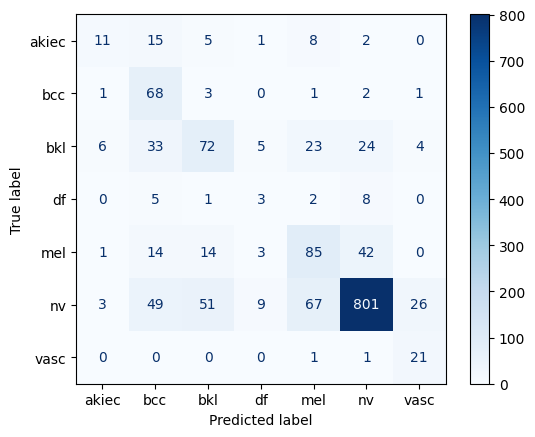

In [45]:
ConfusionMatrixDisplay(
    confusion_matrix=fine_tune_cm,
    display_labels=class_names
).plot(cmap="Blues")

plt.show()

**Compare Frozen & Fine-Tuned MobileNetV2**

In [46]:
fine_tune_comparison_df = pd.DataFrame({
    "Model": [
        "Frozen MobileNetV2",
        "Fine-tuned MobileNetV2"
    ],
    "Test Accuracy": [
        test_accuracy,
        fine_tune_test_accuracy
    ],
    "Weighted F1": [
        weighted_f1,
        fine_tune_weighted_f1
    ],
    "Macro F1": [
        macro_f1,
        fine_tune_macro_f1
    ],
    "Melanoma Recall": [
        melanoma_recall,
        fine_tune_melanoma_recall
    ],
    "Melanoma Precision": [
        melanoma_precision,
        fine_tune_melanoma_precision
    ]
})

fine_tune_comparison_df

,Model,Test Accuracy,Weighted F1,Macro F1,Melanoma Recall,Melanoma Precision
0,Frozen MobileNetV2,0.695710,0.715364,0.51944,0.597484,0.400844
1,Fine-tuned MobileNetV2,0.711126,0.723450,0.48252,0.534591,0.454545


**Accuracy Improvement**

In [47]:
accuracy_change = fine_tune_test_accuracy - test_accuracy

print("Original accuracy:", test_accuracy)
print("Fine-tuned accuracy:", fine_tune_test_accuracy)
print("Accuracy change:", accuracy_change)

Original accuracy: 0.6957104802131653
Fine-tuned accuracy: 0.7111260294914246
Accuracy change: 0.015415549278259277


**Save Fine-Tuned Model**

In [48]:
mobilenet_model.save(
    project_path + "/models/mobilenet/mobilenetv2_finetuned.keras"
)

print("Fine-tuned MobileNetV2 model saved successfully.")

Fine-tuned MobileNetV2 model saved successfully.


# Phase 3: MobileNetV2 Transfer Learning Completed ✅

The frozen MobileNetV2 model achieved better results than the corrected baseline CNN.

## Frozen MobileNetV2 Results

* Test accuracy: **69.57%**
* Weighted F1-score: **71.54%**
* Macro F1-score: **51.94%**
* Melanoma recall: **59.75%**
* Melanoma precision: **40.08%**

## Fine-Tuned MobileNetV2 Results

* Test accuracy: **71.11%**
* Weighted F1-score: **72.35%**
* Macro F1-score: **48.25%**
* Melanoma recall: **53.46%**
* Melanoma precision: **45.45%**

Fine-tuning improved overall accuracy and melanoma precision, but reduced macro F1-score and melanoma recall.

Therefore, the **frozen MobileNetV2 model is selected as the primary final model**, while the fine-tuned model is kept as an experimental comparison.

Models saved at:

* `models/mobilenet/mobilenetv2_model.keras`
* `models/mobilenet/mobilenetv2_finetuned.keras`
